In [49]:
#Nandhini.N

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

In [4]:
(X_train_full,y_train_full),(X_test,y_test)=keras.datasets.mnist.load_data()

In [5]:
X_train,X_val,y_train,y_val=train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=42
)

In [6]:
X_train = X_train / 255.0
X_test = X_test / 255.0
print(X_train.shape)
print(y_train.shape)

(45000, 28, 28)
(45000,)


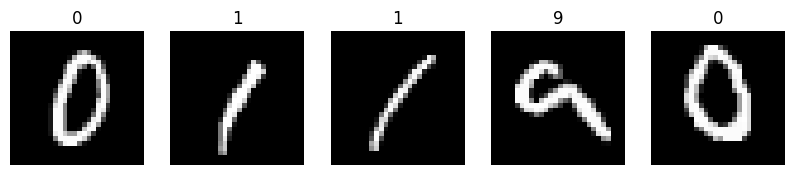

In [7]:
plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.show()

In [8]:
model = tf.keras.Sequential()

In [9]:
model.add(tf.keras.layers.Flatten(input_shape=(28,28)))
model.add(tf.keras.layers.Dense(128, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

C:\microsoft visual studio\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=3
)

Epoch 1/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - accuracy: 0.9173 - loss: 0.2919
Epoch 2/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9622 - loss: 0.1318
Epoch 3/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9733 - loss: 0.0908


In [12]:
loss,accuracy=model.evaluate(X_test,y_test)
print("Accuracy:",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9648 - loss: 0.1058
Accuracy: 0.9648000001907349


In [13]:
y_pred = model.predict(X_test)

pred = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


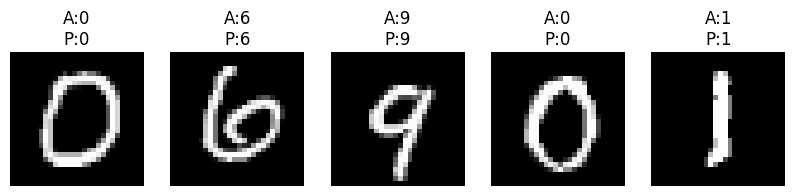

In [16]:
plt.figure(figsize=(10,2))

for i in range(10,15):
    plt.subplot(1,5,i-9)
    plt.imshow(X_test[i], cmap="gray")
    plt.title("A:"+str(y_test[i])+"\nP:"+str(pred[i]))
    plt.axis("off")

plt.show()


Wrong Predictions: 352


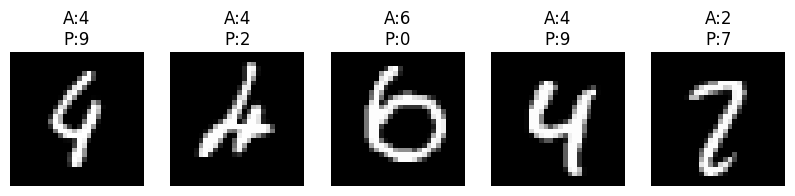

In [17]:
wrong = np.where(pred != y_test)[0]

print("Wrong Predictions:", len(wrong))

plt.figure(figsize=(10,2))

for i in range(5):
    j = wrong[i]
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[j], cmap="gray")
    plt.title("A:"+str(y_test[j])+"\nP:"+str(pred[j]))
    plt.axis("off")

plt.show()